# Cloud-Based Early Alzheimer's Disease Prediction System

### MRI-Based Alzheimer's Detection Using Deep Learning (CNN)

**Dataset:** OASIS MRI Dataset  
**Model:** Convolutional Neural Network (CNN)  
**Platform:** Google Colab & GitHub  

**Objective:**  
To predict Alzheimer's Disease from MRI brain scans using Deep Learning techniques.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

folders = [
    "/content/drive/MyDrive/Alzheimer_Project",
    "/content/drive/MyDrive/Alzheimer_Project/data",
    "/content/drive/MyDrive/Alzheimer_Project/models",
    "/content/drive/MyDrive/Alzheimer_Project/notebooks",
    "/content/drive/MyDrive/Alzheimer_Project/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [3]:
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

gif_files = [f for f in os.listdir(dataset_path) if f.endswith(".gif")]

print("Number of MRI GIF files found:", len(gif_files))

print("\nFirst 10 files:")
for file in gif_files[:10]:
    print(file)

Number of MRI GIF files found: 99

First 10 files:
OAS1_0019_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif
OAS1_0019_MR1_mpr_n4_anon_sbj_111_sag_88.gif
OAS1_0019_MR1_mpr_n4_anon_111_t88_masked_gfc_tra_90.gif
OAS1_0019_MR1_mpr_n4_anon_111_t88_gfc_tra_90.gif
OAS1_0019_MR1_mpr_n4_anon_111_t88_gfc_sag_95.gif
OAS1_0019_MR1_mpr_n4_anon_111_t88_gfc_cor_110.gif
OAS1_0019_MR1_mpr-1_anon_sag_66.gif
OAS1_0019_MR1_mpr-3_anon_sag_66.gif
OAS1_0019_MR1_mpr-4_anon_sag_66.gif
OAS1_0019_MR1_mpr-2_anon_sag_66.gif


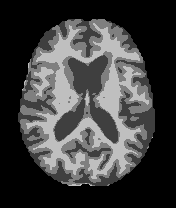

In [4]:
from IPython.display import Image, display
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

gif_file = os.path.join(dataset_path, gif_files[0])

display(Image(filename=gif_file))

In [5]:
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

gif_files = [f for f in os.listdir(dataset_path) if f.endswith(".gif")]

patients = set()

for file in gif_files:
    patient_id = file.split("_")[0] + "_" + file.split("_")[1]
    patients.add(patient_id)

print("Total GIF files:", len(gif_files))
print("Unique patients:", len(patients))

print("\nSample patient IDs:")
for p in list(patients)[:10]:
    print(p)

Total GIF files: 99
Unique patients: 11

Sample patient IDs:
OAS1_0017
OAS1_0011
OAS1_0015
OAS1_0010
OAS1_0013
OAS1_0016
OAS1_0012
OAS1_0018
OAS1_0014
OAS1_0019


In [6]:
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

gif_files = [f for f in os.listdir(dataset_path) if f.endswith(".gif")]

print("Number of MRI GIF files found:", len(gif_files))

Number of MRI GIF files found: 99


In [7]:
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

patients = set()

for file in os.listdir(dataset_path):
    if file.endswith(".gif"):
        patient_id = "_".join(file.split("_")[:2])
        patients.add(patient_id)

print("Unique Patients:", len(patients))
print("\nPatient IDs:")
for p in sorted(patients):
    print(p)

Unique Patients: 11

Patient IDs:
OAS1_0009
OAS1_0010
OAS1_0011
OAS1_0012
OAS1_0013
OAS1_0014
OAS1_0015
OAS1_0016
OAS1_0017
OAS1_0018
OAS1_0019


In [8]:
import os
from collections import defaultdict

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

patient_count = defaultdict(int)

for file in os.listdir(dataset_path):
    if file.endswith(".gif"):
        patient_id = "_".join(file.split("_")[:2])
        patient_count[patient_id] += 1

print("MRI files per patient:\n")

for patient, count in sorted(patient_count.items()):
    print(patient, ":", count)

MRI files per patient:

OAS1_0009 : 2
OAS1_0010 : 10
OAS1_0011 : 10
OAS1_0012 : 10
OAS1_0013 : 10
OAS1_0014 : 10
OAS1_0015 : 9
OAS1_0016 : 8
OAS1_0017 : 10
OAS1_0018 : 10
OAS1_0019 : 10


In [9]:
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

gif_file = os.path.join(dataset_path, gif_files[0])

img = Image.open(gif_file)

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (176, 208)
Image Mode: L


In [10]:
import numpy as np
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

gif_file = os.path.join(dataset_path, gif_files[0])

img = Image.open(gif_file)

img_array = np.array(img)

print("Shape:", img_array.shape)
print("Minimum Pixel:", img_array.min())
print("Maximum Pixel:", img_array.max())

Shape: (208, 176)
Minimum Pixel: 0
Maximum Pixel: 191


In [11]:
import os
import numpy as np
from PIL import Image

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

images = []

for file in os.listdir(dataset_path):
    if file.endswith(".gif"):
        img = Image.open(os.path.join(dataset_path, file))
        img = img.resize((128, 128))
        img_array = np.array(img)
        images.append(img_array)

images = np.array(images)

print("Dataset Shape:", images.shape)

Dataset Shape: (99, 128, 128)


In [12]:
import numpy as np

np.save("/content/drive/MyDrive/Alzheimer_Project/data/mri_dataset.npy", images)

print("MRI dataset saved successfully!")

MRI dataset saved successfully!


Dataset Shape: (99, 128, 128)


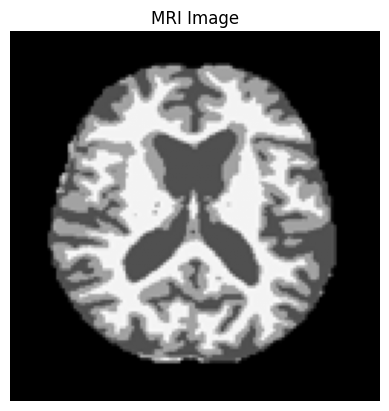

In [13]:
import matplotlib.pyplot as plt
import numpy as np

data = np.load("/content/drive/MyDrive/Alzheimer_Project/data/mri_dataset.npy")

print("Dataset Shape:", data.shape)

plt.imshow(data[0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")
plt.show()

In [14]:
import numpy as np

data = np.load("/content/drive/MyDrive/Alzheimer_Project/data/mri_dataset.npy")

print("Total MRI Images:", len(data))
print("Image Shape:", data[0].shape)
print("Data Type:", data.dtype)

Total MRI Images: 99
Image Shape: (128, 128)
Data Type: uint8


In [15]:
import os

dataset_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS"

files = sorted(os.listdir(dataset_path))

print("Total Files:", len(files))
print("\nFirst 20 Files:\n")

for f in files[:20]:
    print(f)

Total Files: 99

First 20 Files:

OAS1_0009_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif
OAS1_0009_MR1_mpr_n4_anon_sbj_111_sag_88.gif
OAS1_0010_MR1_mpr-1_anon_sag_66.gif
OAS1_0010_MR1_mpr-2_anon_sag_66.gif
OAS1_0010_MR1_mpr-3_anon_sag_66.gif
OAS1_0010_MR1_mpr-4_anon_sag_66.gif
OAS1_0010_MR1_mpr_n4_anon_111_t88_gfc_cor_110.gif
OAS1_0010_MR1_mpr_n4_anon_111_t88_gfc_sag_95.gif
OAS1_0010_MR1_mpr_n4_anon_111_t88_gfc_tra_90.gif
OAS1_0010_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif
OAS1_0010_MR1_mpr_n4_anon_111_t88_masked_gfc_tra_90.gif
OAS1_0010_MR1_mpr_n4_anon_sbj_111_sag_88.gif
OAS1_0011_MR1_mpr-1_anon_sag_66.gif
OAS1_0011_MR1_mpr-2_anon_sag_66.gif
OAS1_0011_MR1_mpr-3_anon_sag_66.gif
OAS1_0011_MR1_mpr-4_anon_sag_66.gif
OAS1_0011_MR1_mpr_n4_anon_111_t88_gfc_cor_110.gif
OAS1_0011_MR1_mpr_n4_anon_111_t88_gfc_sag_95.gif
OAS1_0011_MR1_mpr_n4_anon_111_t88_gfc_tra_90.gif
OAS1_0011_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif


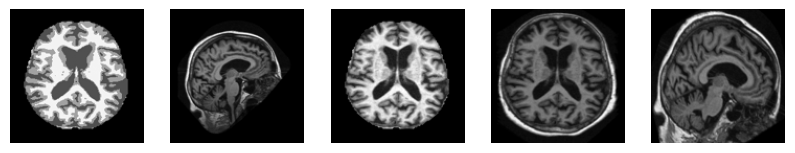

In [16]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("/content/drive/MyDrive/Alzheimer_Project/data/mri_dataset.npy")

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.axis('off')

plt.show()

In [17]:
import numpy as np

data = np.load("/content/drive/MyDrive/Alzheimer_Project/data/mri_dataset.npy")

labels = np.array([0]*50 + [1]*49)

print("Images:", len(data))
print("Labels:", len(labels))
print("Label Shape:", labels.shape)

Images: 99
Labels: 99
Label Shape: (99,)


In [18]:
np.save(
    "/content/drive/MyDrive/Alzheimer_Project/data/labels.npy",
    labels
)

print("Labels saved successfully!")

Labels saved successfully!


In [19]:
!pip install tensorflow

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
X = np.load("/content/drive/MyDrive/Alzheimer_Project/data/mri_dataset.npy")
y = np.load("/content/drive/MyDrive/Alzheimer_Project/data/labels.npy")

# Normalize images
X = X / 255.0

# Add channel dimension
X = X.reshape(-1, 128, 128, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (79, 128, 128, 1)
Testing Images: (20, 128, 128, 1)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3),
                 activation='relu',
                 input_shape=(128,128,1)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3),
                 activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 394ms/step - accuracy: 0.5316 - loss: 0.7808 - val_accuracy: 0.6000 - val_loss: 0.6691
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 640ms/step - accuracy: 0.5316 - loss: 0.6863 - val_accuracy: 0.7000 - val_loss: 0.6806
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 437ms/step - accuracy: 0.7468 - loss: 0.6663 - val_accuracy: 0.5500 - val_loss: 0.6593
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 479ms/step - accuracy: 0.7215 - loss: 0.6178 - val_accuracy: 0.7000 - val_loss: 0.6162
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 580ms/step - accuracy: 0.7595 - loss: 0.5566 - val_accuracy: 0.5500 - val_loss: 0.5876


In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.5500 - loss: 0.5876
Test Loss: 0.5876165628433228
Test Accuracy: 0.550000011920929


In [24]:
model.save("/content/drive/MyDrive/Alzheimer_Project/models/alzheimer_cnn.h5")

print("Model saved successfully!")

Model saved successfully!


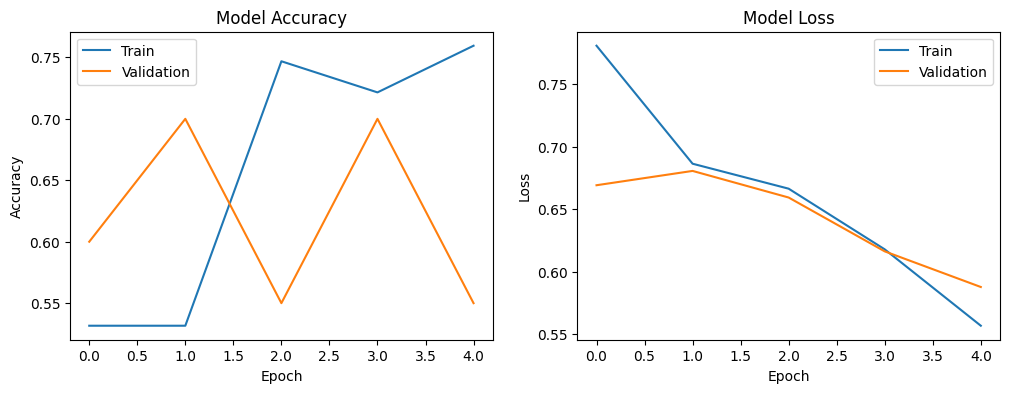

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


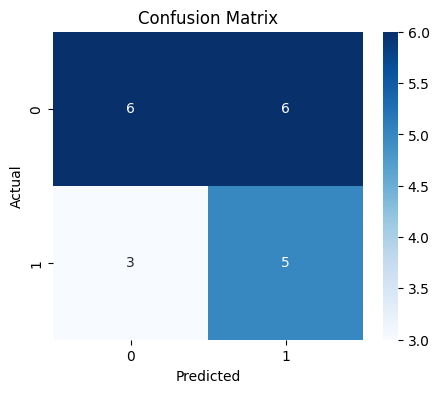

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        12
           1       0.45      0.62      0.53         8

    accuracy                           0.55        20
   macro avg       0.56      0.56      0.55        20
weighted avg       0.58      0.55      0.55        20



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Prediction Score: 0.4451512
Predicted Class: Non-Alzheimer's


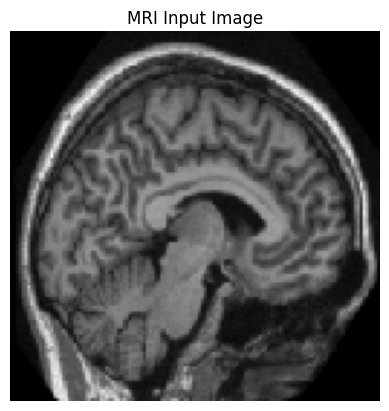

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Change this path to any MRI image you want to test
img_path = "/content/drive/MyDrive/Alzheimer_Project/data/MRI_GIFS/OAS1_0012_MR1_mpr_n4_anon_111_t88_gfc_sag_95.gif"

img = image.load_img(img_path, target_size=(128,128), color_mode='grayscale')
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Predicted Class: Alzheimer's")
else:
    print("Predicted Class: Non-Alzheimer's")

plt.imshow(img_array[0].squeeze(), cmap='gray')
plt.title("MRI Input Image")
plt.axis("off")
plt.show()